<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/logo_uc3m_foot.jpg' width=800 />
</center>


# **Procesamiento del Lenguaje Natural**: Aprendizaje profundo ("Deep Learning").

**Angel Navia Vázquez, Pablo Martínez Olmos, Vanessa Gómez Verdejo, Emilio Parrado Hernández**

  * 1.1 (January 2026) Revised and updated version

Departamento de Teoría de la Señal y Comunicaciones, **Universidad Carlos III de Madrid**


## 1 - Introducción: conceptos básicos del  Aprendizaje profundo ("Deep Learning", DL)

El funcionamiento del cerebro de los mamíferos se puede analizar como una **respuesta combinada y sucesiva** de **múltiples capas de neuronas**. La **información de entrada** es sucesivamente **procesada y transformada** para dar lugar a **representaciones internas**, y finalmente producir una **respuesta**.

Por ejemplo, en el caso del **cortex visual**, se han descrito y modelado diferentes **zonas de procesado**, como las descritas en el modelo del sistema visual humano propuesto por [Simon Thorpe](https://scholar.google.com/citations?user=uR-7ex4AAAAJ&hl=es), tal y como se muestra en la siguiente figura (izquierda):

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/cortex1y2.png' width=800 />
</center>

Vemos que los diferentes **grupos de neuronas** (LGN, V1, V2, V4, PIT) se centran en el procesado de elementos visuales cada vez más complejos, hasta alcanzar una comprensión visual completa (AIT) que puede llevar a la toma de decisiones (PFC) y las consecuentes acciones (PMC, MC).  Esta **identificación funcional** ha servido de inspiración a **modelos de procesado**, como el propuesto por [Gallant & Van Essen](https://www.sciencedirect.com/science/article/abs/pii/0896627394904553), mostrada en la parte derecha de la figura anterior.




Obviamente no vamos a profundizar aquí en dichos modelos biológicos, simplemente vamos a retener la idea de que un **procesado en sucesivas capas neuronales** es importante, pues da lugar a **representaciones intermedias** relevantes. Podemos encontrar [aquí](https://bernardmarr.com/a-short-history-of-deep-learning-everyone-should-read/
) una breve historia de la evolución de las redes profundas.




Según [Geoffrey Hinton](https://www.nature.com/articles/nature14539) (considerado el padre del aprendizaje profundo junto a Yoshua Bengio y Yann LeCun):

"El **aprendizaje profundo (DL)** comprende modelos computacionales compuestos por **múltiples capas de procesamiento** que permiten **aprender representaciones** de datos con **múltiples niveles de abstracción**".

De este modo, la red neuronal no resuelve únicamente la tarea final, sino que **obtiene representaciones intermedias relevantes**. Estas interpretaciones han dado lugar a los primeros modelos **precursores de aprendizaje profundo**. Por ejemplo, el modelo de [**Yann LeCun**](https://ieeexplore.ieee.org/document/6795724) (1989) para el **reconocimiento de dígitos manuscritos**:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/LeCun_handwritten.png' width=500 />
</center>



Dicho modelo evolucionó para dar lugar a la **primera red neuronal convolucional** [LeNet (1998)](https://ieeexplore.ieee.org/document/726791), en la que se definen formalmente por primera vez los conceptos de "**capa convolucional**" y "capa con submuestreo" (**subsamplig**):

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/LeNet.png' width=800 />
</center>


Estas arquitecturas convolucionales darían lugar a modelos cada vez más complejos, como [**AlexNet**](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf), una CNN profunda con **60 millones de parámetros** que gana en 2012 la competición **"ImageNet Classification Contest"** de clasificación de imágenes (1000 categorías), donde se añaden nuevos conceptos, como las capas de "**max-pooling**":

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/alexnet.png' width=800 />
</center>

Sus autores se han convertido en **referentes mundiales en el aprendizaje automático/AI**: **Alex Krizhevsky** (DNN Research Inc., vendida a Google), **Ilya Sutskever** (co-fundador de OpenAI) y **Geoffrey Hinton** (Premio Nobel de Física 2024).  


Un aspecto fundamental de este tipo de redes es que no sólo aprenden a resolver una tarea, sino que obtienen **representaciones internas jerárquicas** de la información. Por ejemplo, veamos las representaciones internas de una red profunda utilizada para el reconocimiento de caras:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/cnn_features.jpg' width=800 />
</center>

Las primeras capas se centran en el procesado de **características muy básicas**, y a medida que progresamos en la red, se van construyendo **representaciones de más alto nivel**, lo cual está totalmente correlacionado con lo observado en los modelos del cortex cerebral humano descritos anteriormente.


## 2 - Protocolo general de entrenamiento

Es habitual seguir un **protocolo adecuado de entrenamiento** para obtener buenos resultados. Definiremos los siguientes subconjuntos de datos:

- **Datos de entrenamiento**: utilizados para ajustar los **parámetros libres del modelo (pesos)**.

- **Datos de validación**: no utilizado para el ajuste de los pesos, pero sí para validar las prestaciones del modelo en datos no usados durante el entrenamiento. Esta comprobación puede servir para **elegir otros hiperparámetros del modelo** (número de capas, número de neuronas por capa, tipo de capas, tipo de activación, función de coste, número de épocas de entrenamiento, etc.). En algunos casos será posible sustituir este conjunto por un procedimiento de validación cruzada (e.g. "**N-fold cross validation**").

- **Datos de test**: utilizados únicamente al final de todas las pruebas, para medir **prestaciones FINALES del modelo**. Lo que se observe sobre el conjunto de test **NO puede utilizarse** para reajustar ninguno de los parámetros o hiperparámetros del modelo. **Tampoco puede utilizarse el conjunto de test para elegir el mejor modelo entre varios disponibles**.

Se debería cumplir que **todos estos subconjuntos de datos proceden de la misma distribución**, es decir, tienen las mismas probabilidades estadísticas. Podría ocurrir que los datos a procesar en el futuro por el modelo se fueran alejando de dicha distribución y por tanto las prestaciones del modelo podrían ir disminuyendo. este fenómeno se conoce como **"concept drift"**. La detección de esta situación y su subsanación excede los objetivos de este curso.

### 2.1 - Sobreajuste del entrenamiento (over-fitting)

Si el modelo tiene **muchos grados de libertad** (gran número de parámetros libres respecto al número de patrones de entrenamiento), el ajuste de los pesos puede llevar a una sobre-especialización (ing. **"over-fitting"**) que provoca que el modelo se **AJUSTE DEMASIADO BIEN a los datos de entrenamiento, en detrimento de sus prestaciones en otros conjuntos de datos (validación o test)**.


Este problema es bien conocido en el ámbito del aprendizaje, y se conoce también como el problema de **sesgo-varianza** (["bias-variance"](https://www.cs.cornell.edu/courses/cs4780/2018fa/lectures/lecturenote12.html)). El **sesgo** mide la **desviación promedio** respecto de la solución ideal y la **varianza** mide la **variabilidad en la predicción de un punto determinado**. Podemos ilustrarlo con el siguiente [ejemplo](http://scott.fortmann-roe.com/docs/BiasVariance.html):


<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/bias_variance.png' width=400 />
</center>


### 2.2 Regularización

En nuestro contexto de aprendizaje, podemos identificar

- situaciones de **alta varianza**, caracterizadas porque el error en el conjunto de entrenamiento es mucho menor que en el de test. Habría que **reducir la complejidad del modelo, aplicar técnicas de regularización o utilizar más datos de entrenamiento**.

- situaciones de **alto sesgo**, en los que el modelo no es capaz de proporcionar una solución válida. Habría que **ajustar más los pesos del modelo, utilizar un modelo más complejo o potente, o cambiar las características de entrada** (parametrizaciones de los datos).  

Obviamente, la **situación ideal es la de bajo sesgo y baja varianza**, que indica que los modelos se ajustan muy bien a los datos, tanto de entrenamiento como de validación y test.

En temas anteriores ya hemos visto alguna técnica de regularización de modelos. Concretamente en el caso del Regresor Logístico, veíamos que añadir una **penalización en la función de coste sobre el valor de los pesos** (norma $L_1$, $L_2$, etc.), ayudaba a controlar la magnitud de los mismos y se reducía el overfitting. Vamos a ver a continuación técnicas complementarias, más orientadas al entrenamiento de redes neuronales.  

#### 2.2.1 Regularización por "early stopping"

Una forma de controlar el sobreentrenamiento es **monitorizar la evolución de la función de coste durante el entrenamiento** y **detener el proceso cuando se observe un repunte en las prestaciones de validación**. Esta aproximación se considera un método de regularización y se denomina "**early stopping**".

En la siguiente figura podemos ver la **evolución del coste** durante el entrenamiento, tanto para el conjunto de **entrenamiento** como para el de **validación**:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/overfitting_bias_variance.PNG' width=600 />
</center>

- Al principio del entrenamiento estamos en una situación de **alto sesgo** (el ajuste es malo) y **baja varianza** (cambios en las entradas apenas afectan a las salidas), pero los resultados no son satisfactorios ni para entrenamiento ni para validación/test.

- Si dejamos evolucionar mucho el entrenamiento llegamos a una situación en la que **el modelo memoriza los datos de entrenamiento** (sesgo muy bajo), incluyendo el ruido y las particularidades estadísticas que no se repiten en otros conjuntos y por tanto generaliza mal. El modelo se ha vuelto tan sensible que pequeños cambios en los datos de entrada producen resultados radicalmente distintos (**alta varianza**).

- La situación **ideal ("bias-variance trade-off" o "sweet spot")** se produce en un **punto intermedio del entrenamiento**, justo cuando la curva de validación comienza a repuntar: el modelo ha aprendido el "ruido" mínimo y la "señal" máxima. En ese momento se debería **detener el entrenamiento**.

#### 2.2.2 Regularización de redes neuronales mediante "drop-out"

Otra forma de conseguir un control sobre el entrenamiento de redes neuronales es aplicar lo que se conoce **"drop-out"**: una **desactivación aleatoria de parte de las activaciones durante el entrenamiento** de la red, lo que **limita la capacidad de la red para memorizar los datos de entrenamiento**, reduciendo por tanto el sobreajuste.

A modo de ejemplo, tal y como se describe en el artículo [**"Dropout: A Simple Way to Prevent Neural Networks from Overfitting"**](https://jmlr.org/papers/v15/srivastava14a.html), de N. Srivastava, G. Hinton, A. Krizhevsky y I. Sutskever, tendríamos una red neuronal totalmente conectada tal y como se representa en la siguiente figura, parte (a).

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/dropout.png' width=600 />
</center>

Ahora bien, **sólo a efectos de entrenamiento y para la retropropagación de los errores**, la red "activa" podría ser la indicada en la figura (b), de modo que **no todas las neuronas en capas más profundas reciben todos los errores**. El procentaje de conexiones que se "eliminan" se determina mediante un parámetro conocido como **probabilidad de dropout**, y tal y como su nombre sugiere, implica que **en cada época las conexiones que se desconectan se eligen aleatoriamente**.  

En la parte experimental del tema veremos cómo se aplican tanto el **"early stopping"** como el **"dropout"**. Recordemos que el **dropout sólo se aplica durante la fase de entrenamiento**, el modelo final es el completo, **contiene todas las neuronas**.

#### 2.2.3 Regularización por aumento de datos (Data Augmentation)

Esta es la tercera opción que tenemos, **aumentar la cantidad de datos disponibles para el entrenamiento**. Como esto no siempre es posible, pues puede no haber más datos naturales disponibles, la técnica de **aumento de datos (Data Augmentation) propone sintetizar nuevos datos de entrenamiento a partir de los disponibles**. Dependiendo del contexto, será más o menos factible. Por ejemplo, en clasificación de imágenes podemos generar nuevos patrones mediante transformaciones por traslación, rotación, escalado, recorte, etc., como se ilustra en el siguiente ejemplo, todas las nuevas imágenes obtenidas corresponden a la categoría "perro", y permitirían a la red detectar perros en diferentes posiciones/ubicaciones dentro de la imagen:


<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/data_augmentation.png' width=600 />
</center>


##3 - Ejemplo de entrenamiento de redes profundas

Vamos a utilizar la base de datos de imágenes [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) para experimentar con las diferentes redes profundas presentadas en este tema. La base de datos contiene un conjunto de imágenes de prendas de vestir en escala de grises de tamaño 28x28 píxeles (baja resolución) clasificadas en 10 categorías. Esta base de datos ha sido profusamente utilizada en la literatura, y los mejores modelos alcanzan casi un $100\%$ de acierto en test (podemos acceder [aquí](https://paperswithcode.com/sota/image-classification-on-fashion-mnist?metric=Accuracy) a la tabla de prestaciones de los diferentes modelos en este dataset).

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/sample_FMNIST2.png' width=800 />
</center>

Esta base de datos es suficientemente compleja como para que un MLP no encuentra una buena solución en términos de generalización en datos de test y acabe **sobreajustando el modelo**. Aprenderemos aquí cómo controlar el sobreajuste con **early stopping** y **dropout**.


### 3.1 - Descarga de FMNIST con `torchvision`

La base de datos puedes descargarse de forma sencilla a través del paquete [**`torchvision`**](https://pytorch.org/docs/stable/torchvision/index.html), que proporciona datasets de uso común, arquitecturas de modelos y transformaciones de imágenes habituales para aplicaciones de visión por ordenador.

El siguiente código descargará el conjunto de datos FMNIST y luego creará conjuntos de datos de entrenamiento y test. La librería [``torchvision.transforms``](https://pytorch.org/vision/0.9/transforms.html) proporciona una gran variedad de técnicas de preprocesado que se pueden aplicar sobre las imágenes.

=================================================================

**Nota:** A fin de ejecutar los modelos con mayor velocidad, conviene **activar la GPU en Google Colab**:

- **Entorno de ejecución** > Cambiar tipo de entorno de ejecución (``Change runtime type``).
- En **Acelerador de hardware** (``Hardware accelerator``), selecciona **``GPU T4``** (NVIDIA Tesla T4, 16 GB de VRAM) y guardar configuración.

=================================================================

In [ ]:
# Ejecutamos este código para preparar el contexto.
from IPython.core.display import Image, display
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib import cm

# Configuración de las figuras matplotlib
plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams.update({'font.size': 12})

In [ ]:
# Estas librerías pueden dar problemas de dependencias, conviene instalarlas conjuntamente, para que pip resuelva correctamente las dependencias
!pip install --upgrade numpy pandas scipy gensim spacy nltk torch

In [ ]:
import numpy as np
import scipy
import pandas as pd
import spacy
import gensim
import nltk
import torch

print(f"NumPy version: {np.__version__}")
print(f"Scipy version: {scipy.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Spacy version: {spacy.__version__}")
print(f"Gensim version: {gensim.__version__}")
print(f"NLTK version: {nltk.__version__}")
print(f"PyTorch version: {nltk.__version__}")

# 2025
# NumPy version: 1.26.4
# Scipy version: 1.13.1
# Pandas version: 2.2.3
# Spacy version: 3.8.4
# Gensim version: 4.3.3
# NLTK version: 3.9.1
# PyTorch version: 2.6.0+cu124

# 2026
# NumPy version: 2.4.2
# Scipy version: 1.17.0
# Pandas version: 3.0.1
# Spacy version: 3.8.11
# Gensim version: 4.4.0
# NLTK version: 3.9.2
# PyTorch version: 3.9.2


NumPy version: 2.4.2
Scipy version: 1.17.0
Pandas version: 3.0.1
Spacy version: 3.8.11
Gensim version: 4.4.0
NLTK version: 3.9.2
PyTorch version: 3.9.2


In [ ]:
# Importamos los elementos que necesitamos de PyTorch:
from torch import nn
from torch import optim
from torch.utils.data import Dataset
from torchvision import datasets, transforms

In [ ]:
# Define a transform to normalize the data
transform_2tensor_norm = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform_2tensor_norm
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform_2tensor_norm
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 274kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.07MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.9MB/s]


In [ ]:
print(type(training_data))
print(training_data)
print(training_data.data.shape)

<class 'torchvision.datasets.mnist.FashionMNIST'>
Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )
torch.Size([60000, 28, 28])


In [ ]:
print(type(test_data))
print(test_data)
print(test_data.data.shape)

<class 'torchvision.datasets.mnist.FashionMNIST'>
Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )
torch.Size([10000, 28, 28])


In [ ]:
# A través de .classes accedemos a las categorías disponibles:
labels_map ={idx:label for idx, label in enumerate(training_data.classes)}
print("Estas son las categorías disponibles:\n\n {}".format(labels_map))

# El atributo .targets nos proporciona todas las etiquetas
all_labels = training_data.targets
print("\nCon el atributo .targets accedemos a todas las etiquetas, hay {} etiquetas, son de tipo {} y estos son los diferentes valores:\n\n {}".format(len(all_labels), type(all_labels), set(all_labels.tolist())))

# .data nos proporciona todas las etiquetas
data = training_data.data
print("\nCon el atributo .data accedemos a los datos de entrada, es de tipo {} y tiene tamaño {}.".format(type(data), data.shape))

print("\nVemos por tanto que los datos de entrada están estructurados en forma de tensor: N imágenes de tamaño MXM")


Estas son las categorías disponibles:

 {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}

Con el atributo .targets accedemos a todas las etiquetas, hay 60000 etiquetas, son de tipo <class 'torch.Tensor'> y estos son los diferentes valores:

 {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

Con el atributo .data accedemos a los datos de entrada, es de tipo <class 'torch.Tensor'> y tiene tamaño torch.Size([60000, 28, 28]).

Vemos por tanto que los datos de entrada están estructurados en forma de tensor: N imágenes de tamaño MXM


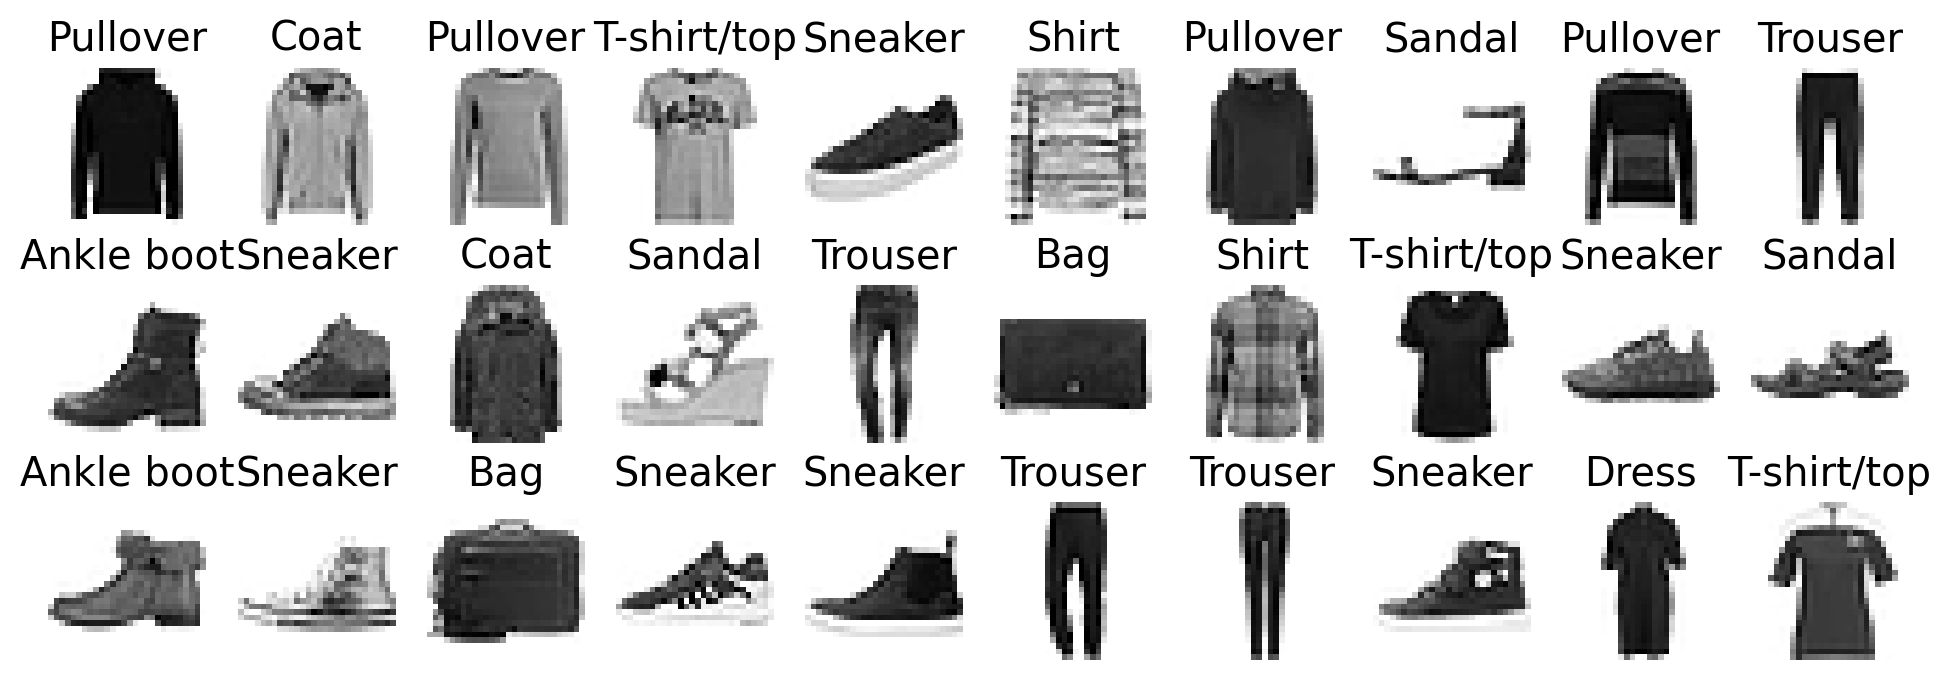

In [ ]:
figure = plt.figure(figsize=(12, 4))
cols, rows = 10, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(-img.squeeze(), cmap="gray")
plt.show()

### 3.2 - Entrenamiento de una red profunda con "early stopping".

En el siguiente código definimos una **red MLP con cuatro capas**, un vector unidimensional de tamaño ``dimx`` (28x28=784) a la entrada,  capas ocultas con 256, 128 y 64 neuronas, 10 neuronas en la capa de salida (una por cada clase), y activaciones en las capas intermedias de tipo ReLU.

Como ahora tenemos un clasificador multi-clase
utilizaremos una capa *softmax* en la salida para calcular las probabilidades de clase. En el código que se proporciona, se usa `nn.LogSoftmax` en lugar de `nn.Softmax ()`, que devuelve el **logaritmo** de la probabilidad de cada clase. Habría por tanto que aplicar una **exponenciación final para obtener las probabilidades**.

In [ ]:
class MLP(nn.Module):
    def __init__(self, dimx, n_hidden1, n_hidden2, n_hidden3, n_labels=10): #Nlabels will be 10 in our case
        super().__init__()
        self.capa1 = nn.Linear(dimx, n_hidden1)
        self.capa2 = nn.Linear(n_hidden1, n_hidden2)
        self.capa3 = nn.Linear(n_hidden2, n_hidden3)
        self.capa_final = nn.Linear(n_hidden3, n_labels)
        self.activation = nn.ReLU()
        #self.activation = nn.Sigmoid()
        self.logsoftmax = nn.LogSoftmax(dim=1) #Con dim=1 indicamos que cada fila a la salida de la función de activación suma 1

    def forward(self, x):

        x = self.capa1(x)
        x = self.activation(x)

        x = self.capa2(x)
        x = self.activation(x)

        x = self.capa3(x)
        x = self.activation(x)

        x = self.capa_final(x)
        x = self.logsoftmax(x)
        return x

**Extendemos la clase añadiendo método de entrenamiento**. Esta clase es muy parecida a la del notebook anterior, con dos pequeñas diferencias:

* Reemplazamos la función de coste, ahora usamos `nn.NLLLoss()` (Negative Log Likelihood Loss para problemas de clasificación con N clases).

* Ahora **usamos el optimizador Adam**, descrito en este artículo [Adam: A Method for Stochastic Optimization](https://arxiv.org/abs/1412.6980), que es más eficiente que el gradiente estocástico básico. Dicho optimizador también está disponible en ``PyTorch``.

* Iteramos sobre un ``DataLoader``, para mayor eficiencia. Preparamos por tanto los datos de entrenamiento y test usando la clase  [**`DataLoader`**](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html), que permite convertir los dataset en formato tensor a un iterable con opción de muestreo (para seleccionar aleatoriamente mini-batchs) durante el entrenamiento. Obtenemos por tanto los elementos **`trainloader`** y **`testloader`**.


In [ ]:
class MLP_train(MLP):  # Heredamos de la clase MLP
    def __init__(self, dimx, n_hidden1, n_hidden2, n_hidden3, n_labels, n_epochs=100, lr=0.001):
        super().__init__(dimx, n_hidden1, n_hidden2, n_hidden3, n_labels)  #Inicializamos el MLP
        self.lr = lr #Learning Rate
        # Optimizador Adam
        self.optim = optim.Adam(self.parameters(), self.lr)
        self.n_epochs = n_epochs
        self.criterion = nn.NLLLoss()
        self.loss_during_training = []

        print("Loss: {}".format(self.criterion))
        print("Activación: {}".format(self.activation))

    def fit(self, trainloader):
      print("Comienza el entrenamiento del MLP:")
      # Optimization Loop
      for e in range(int(self.n_epochs)):
          running_loss = 0.
          for images, labels in trainloader:
              self.optim.zero_grad()  #Reiniciamos gradientes en cada época
              out = self.forward(images.view(images.shape[0], -1))
              #Función de coste en el batch
              loss = self.criterion(out, labels)
              running_loss += loss.item()

              #Calculamos gradientes por retropropagación
              loss.backward()

              #Una iteración de descenso por gradiente
              self.optim.step()

          self.loss_during_training.append(running_loss/len(trainloader))

          if(e % 10 == 0): # Every 10 epochs
              print("Training loss after %d epochs: %f"
                    %(e,self.loss_during_training[-1]))

Entrenamos a continuación el modelo usando **`trainloader`** como entrada de datos y mostramos la evolución del coste sobre el conjunto de entrenamiento durante el aprendizaje. Usamos también la siguiente función para calcular el porcentaje de etiquetas correctas en entrenamiento y test. Observad que hacemos el **cálculo por mini-batches**.

Como la red que vamos a utilizar requiere un **vector unidimensional a la entrada**, transformamos las imágenes en vectores de tamaño $28 \times 28 = 784$:

In [ ]:
NPtrain = training_data.data.shape[0]
Size_im1 = training_data.data.shape[1]
Size_im2 = training_data.data.shape[2]
training_data.data = training_data.data.reshape([NPtrain, Size_im1*Size_im2])
print(training_data.data.shape)

NPtest = test_data.data.shape[0]
Size_im1 = test_data.data.shape[1]
Size_im2 = test_data.data.shape[2]
test_data.data = test_data.data.reshape([NPtest, Size_im1*Size_im2])
print(test_data.data.shape)


torch.Size([60000, 784])
torch.Size([10000, 784])


In [ ]:
batch_size = 512
import copy

train_loader = torch.utils.data.DataLoader(training_data, batch_size=batch_size, shuffle=True)

# Guardamos la totalidad de los datos de entrenamiento
train_loader_all = copy.deepcopy(train_loader)

# Tomamos las primeras X imágenes para entrenamiento, para reducir tiempos de entrenamiento durante la clase
# Se puede cambiar luego a la totalidad de los datos (60.000)...
NPtrain = 1000
train_loader = copy.deepcopy(train_loader_all)  # Inicializamos los nuevos Data loaders
train_loader.dataset.data = train_loader_all.dataset.data[:NPtrain,:]
train_loader.dataset.targets = train_loader_all.dataset.targets[:NPtrain]

test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

In [ ]:
# Neuronas en cada capa intermedia:
n_hidden1=256
n_hidden2=128
n_hidden3=64

n_epochs=100
learning_rate = 0.005

fmnist_MLP = MLP_train(dimx=784, n_hidden1=n_hidden1, n_hidden2=n_hidden2, n_hidden3=n_hidden3, n_labels=10, n_epochs=n_epochs, lr=learning_rate)
fmnist_MLP.fit(train_loader)


Loss: NLLLoss()
Activación: ReLU()
Comienza el entrenamiento del MLP:
Training loss after 0 epochs: 2.231274
Training loss after 10 epochs: 0.542378
Training loss after 20 epochs: 0.271509
Training loss after 30 epochs: 0.120394
Training loss after 40 epochs: 0.039895
Training loss after 50 epochs: 0.008902
Training loss after 60 epochs: 0.003394
Training loss after 70 epochs: 0.001367
Training loss after 80 epochs: 0.000835
Training loss after 90 epochs: 0.000629


Train accuracy 1.0
Test accuracy 0.7892520680147059


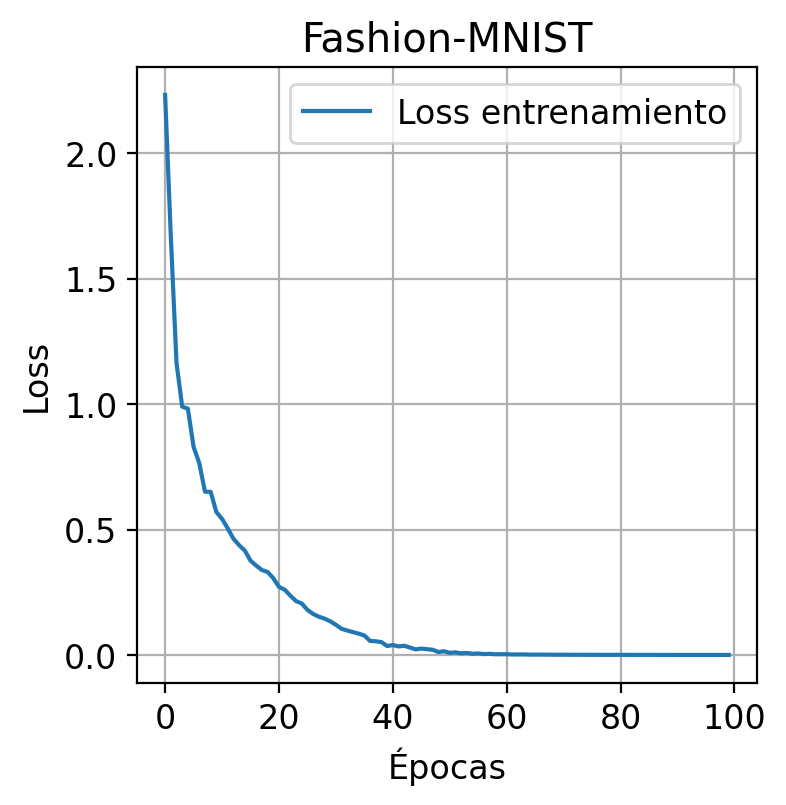

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(fmnist_MLP.loss_during_training, label = "Loss entrenamiento")
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(loc='best' )
plt.title("Fashion-MNIST")
plt.grid()

from sklearn.metrics import accuracy_score

def accuracy(dataloader, model):
    # Turn off gradients for validation, saves memory and computations
    with torch.no_grad():
        accuracy = 0.
        for images,labels in dataloader:
            logprobs = model.forward(images.view(images.shape[0], -1)).detach().numpy()
            prediction = np.argmax(logprobs,1)
            accuracy += accuracy_score(labels.numpy(),prediction,normalize=True)
        return accuracy/len(dataloader)

print(f"Train accuracy {accuracy(train_loader, fmnist_MLP)}")
print(f"Test accuracy {accuracy(test_loader, fmnist_MLP)}")

A la vista de estos resultados, vemos que el modelo presenta mucho mejores prestaciones en el conjunto de entrenamiento que en el conjunto de test. Este es un **signo de sobreajuste**. Para una detección temprana del sobreajuste, haremos uso de un **conjunto de validación** que usaremos para visualizar la evolución de la función de pérdida durante el entrenamiento y así implementar el método **"early stopping"**.




Con el siguiente código, **elegimos como conjunto de validación las siguientes 1.000 imágenes**. Habitualmente se utiliza una partición aleatoria de los datos de entrenamiento, por ejemplo del tipo $80\%/20\%$, para definir los conjuntos de entrenamiento y validación, respectivamente.


In [ ]:
valid_loader = copy.deepcopy(train_loader_all)  # Inicializamos los nuevos Data loaders
valid_loader.dataset.data = train_loader_all.dataset.data[NPtrain:2*NPtrain,:]
valid_loader.dataset.targets = train_loader_all.dataset.targets[NPtrain:2*NPtrain]

#### Ejercicio:

Complete el código de la siguiente  clase, en la que modificamos la clase `MLP_train` anterior para que, durante el entrenamiento, cada vez que termine una época, calcule la función de pérdida sobre el conjunto de validación. Debe almacenar estos valores en un nombre de lista como `valid_loss_during_training`. Al realizar este paso, no olvide "apagar los gradientes" usando `with torch.no_grad()`.

Luego, repita el entrenamiento (50 épocas) y dibuje la evolución de la función de coste tanto para entrenamiento como para validación.


In [ ]:
<INSERTE SU CÓDIGO AQUÍ>

#### Solución:

In [ ]:
class MLP_train_val(MLP):  # Heredamos de la clase MLP
    def __init__(self, dimx, n_hidden1, n_hidden2, n_hidden3, n_labels, n_epochs=100, lr=0.001):
        super().__init__(dimx, n_hidden1, n_hidden2, n_hidden3, n_labels)  #Inicializamos el MLP
        self.lr = lr #Learning Rate
        self.optim = optim.Adam(self.parameters(), self.lr)
        self.n_epochs = n_epochs
        self.criterion = nn.NLLLoss()

        print("Loss: {}".format(self.criterion))
        print("Activación: {}".format(self.activation))

        self.train_loss_during_training = []
        self.valid_loss_during_training = []

    def fit(self, trainloader,validloader):
        # Optimization Loop
        print("Comienza el entrenamiento del MLP con validación:")
        for e in range(int(self.n_epochs)):
            running_loss = 0.
            for images, labels in trainloader:
                self.optim.zero_grad()  #Reiniciamos gradientes en cada época
                out = self.forward(images.view(images.shape[0], -1))
                #Función de coste en el batch
                loss = self.criterion(out,labels)
                running_loss += loss.item()

                #Calculamos gradientes
                loss.backward()

                #Una iteración de descenso por gradiente
                self.optim.step()

            self.train_loss_during_training.append(running_loss/len(trainloader))

            # Desabilitamos gradientes para calcular el coste en validación
            with torch.no_grad():
                running_loss = 0.
                for images, labels in validloader:
                    out = self.forward(images.view(images.shape[0], -1))
                    loss = self.criterion(out,labels)
                    running_loss += loss.item()
                self.valid_loss_during_training.append(running_loss/len(validloader))

            if(e % 10 == 0): # Every 10 epochs
                print("Training and validation loss after %d epochs: %f \t %f"
                      %(e, self.train_loss_during_training[-1], self.valid_loss_during_training[-1]))

In [ ]:
n_epochs=50
fmnist_MLP_val = MLP_train_val(dimx=784, n_hidden1=n_hidden1, n_hidden2=n_hidden2, n_hidden3=n_hidden3, n_labels=10, n_epochs=n_epochs, lr=learning_rate)
fmnist_MLP_val.fit(train_loader, valid_loader)

Loss: NLLLoss()
Activación: ReLU()
Comienza el entrenamiento del MLP con validación:
Training and validation loss after 0 epochs: 2.263311 	 1.954720
Training and validation loss after 10 epochs: 0.533011 	 0.622376
Training and validation loss after 20 epochs: 0.248769 	 0.615860
Training and validation loss after 30 epochs: 0.115512 	 0.730931
Training and validation loss after 40 epochs: 0.038559 	 0.878572


Train accuracy 0.9990234375
Test accuracy 0.7923713235294118


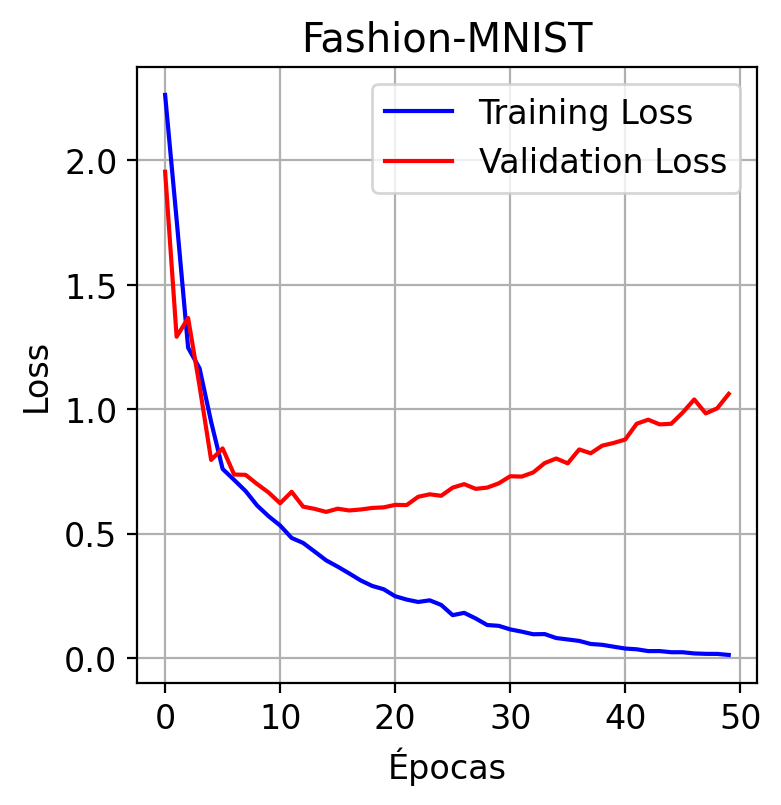

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(fmnist_MLP_val.train_loss_during_training, 'b', label='Training Loss')
plt.plot(fmnist_MLP_val.valid_loss_during_training, 'r', label='Validation Loss')
plt.title("Fashion-MNIST")
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(loc='best' )
plt.grid()

print(f"Train accuracy {accuracy(train_loader, fmnist_MLP_val)}")
print(f"Test accuracy {accuracy(test_loader, fmnist_MLP_val)}")

Vemos que aunque el coste en entrenamiento sigue una trayectoria siempre descendiente, el comportamiento en el conjunto de validación nos indica que hay un punto en el cual el coste en el conjunto de validación se **estanca o incluso comienza a empeorar**, lo que indica una pérdida de generalización. **En ese momento se debe detener el entrenamiento del modelo**.


### 3.3 - Entrenamiento con dropout

Veremos aquí cómo se utiliza el **"dropout"**, en un intento de mejorar la generalización. Añadiremos por tanto capas de tipo "dropout" a la red, ``Pytorch`` aplicará directamente la técnica durante la optimización.

In [ ]:
class MLP_dropout(nn.Module):
    def __init__(self, dimx, n_hidden1, n_hidden2, n_hidden3, n_labels=10): #Nlabels will be 10 in our case
        super().__init__()
        self.capa1 = nn.Linear(dimx, n_hidden1)
        self.capa2 = nn.Linear(n_hidden1, n_hidden2)
        self.capa3 = nn.Linear(n_hidden2, n_hidden3)
        self.capa_final = nn.Linear(n_hidden3, n_labels)
        # Definimos la capa de dropout, con una probabilidad de 0.5 por defecto
        self.dropout = nn.Dropout(p=0.5)
        self.activation = nn.ReLU()
        self.logsoftmax = nn.LogSoftmax(dim=1) #Con dim=1 indicamos que cada fila a la salida de la función de activación suma 1

    def forward(self, x):
        # Aplicamos dropout tras la activación de las capas internas
        x = self.capa1(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.capa2(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.capa3(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.capa_final(x)
        x = self.logsoftmax(x)
        return x

In [ ]:
class MLP_train_val_dropout(MLP_dropout):  # Heredamos de la clase MLP
    def __init__(self, dimx, n_hidden1, n_hidden2, n_hidden3, n_labels, n_epochs=100, lr=0.001):
        super().__init__(dimx, n_hidden1, n_hidden2, n_hidden3, n_labels)  #Inicializamos el MLP
        self.lr = lr #Learning Rate
        self.optim = optim.Adam(self.parameters(), self.lr)
        self.n_epochs = n_epochs
        self.criterion = nn.NLLLoss()

        print("Loss: {}".format(self.criterion))
        print("Activación: {}".format(self.activation))

        self.train_loss_during_training = []
        self.valid_loss_during_training = []

    def fit(self, trainloader,validloader):
        # Optimization Loop
        print("Comienza el entrenamiento del MLP con validación:")
        for e in range(int(self.n_epochs)):
            running_loss = 0.
            for images, labels in trainloader:
                self.optim.zero_grad()  #Reiniciamos gradientes en cada época
                out = self.forward(images.view(images.shape[0], -1))
                #Función de coste en el batch
                loss = self.criterion(out,labels)
                running_loss += loss.item()

                #Calculamos gradientes
                loss.backward()

                #Una iteración de descenso por gradiente
                self.optim.step()

            self.train_loss_during_training.append(running_loss/len(trainloader))

            # Desabilitamos gradientes para validación
            with torch.no_grad():
                running_loss = 0.
                for images, labels in validloader:
                    out = self.forward(images.view(images.shape[0], -1))
                    loss = self.criterion(out,labels)
                    running_loss += loss.item()
                self.valid_loss_during_training.append(running_loss/len(validloader))

            if(e % 10 == 0): # Every 10 epochs
                print("Training and validation loss after %d epochs: %f \t %f"
                      %(e, self.train_loss_during_training[-1], self.valid_loss_during_training[-1]))

In [ ]:
n_epochs=50
fmnist_MLP_val_dropout = MLP_train_val_dropout(dimx=784, n_hidden1=n_hidden1, n_hidden2=n_hidden2, n_hidden3=n_hidden3, n_labels=10, n_epochs=n_epochs, lr=learning_rate)
fmnist_MLP_val_dropout.fit(train_loader, valid_loader)

Loss: NLLLoss()
Activación: ReLU()
Comienza el entrenamiento del MLP con validación:
Training and validation loss after 0 epochs: 2.286775 	 2.148440
Training and validation loss after 10 epochs: 0.882415 	 0.950465
Training and validation loss after 20 epochs: 0.612558 	 0.822392
Training and validation loss after 30 epochs: 0.506003 	 0.767131
Training and validation loss after 40 epochs: 0.401570 	 0.824024


Train accuracy 0.9989754098360656
Test accuracy 0.7920266544117647


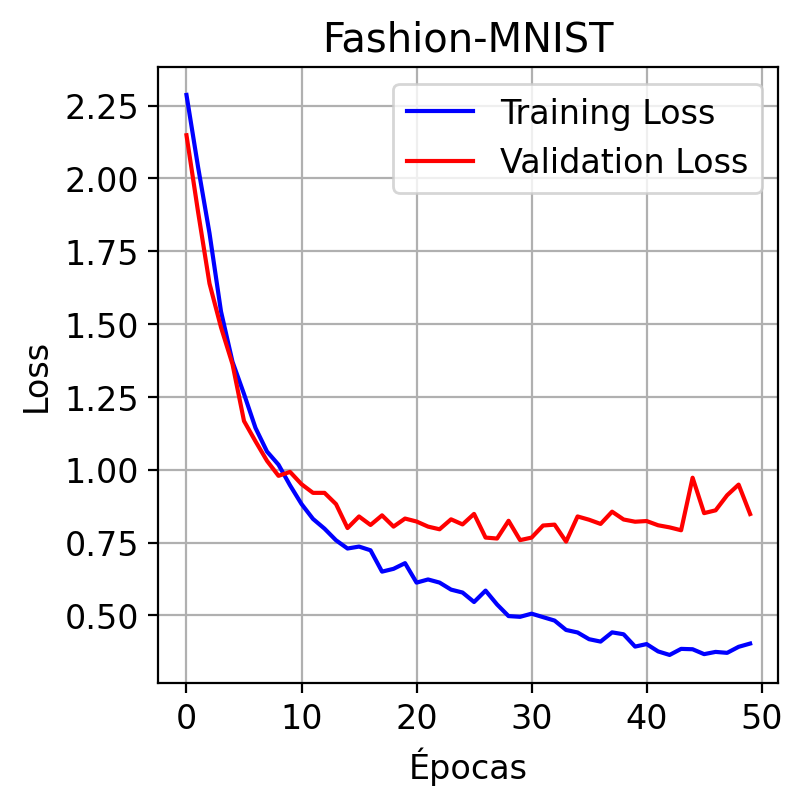

In [ ]:
plt.figure(figsize=(4,4))
plt.plot(fmnist_MLP_val_dropout.train_loss_during_training, 'b', label='Training Loss')
plt.plot(fmnist_MLP_val_dropout.valid_loss_during_training, 'r', label='Validation Loss')
plt.title("Fashion-MNIST")
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(loc='best' )
plt.grid()

print(f"Train accuracy {accuracy(train_loader, fmnist_MLP_val)}")
print(f"Test accuracy {accuracy(test_loader, fmnist_MLP_val)}")

Vemos que ahora gracias al uso de "dropout" el repunte del conjunto de validación es menor. **Combinado con el método de "early stopping" nos indica que debemos detener el entrenamiento tras unas 20 épocas de entrenamiento**.

## 4 - Distintos tipos de capas en una red profunda


En una red profunda las **diferentes capas pueden tener distintas implementaciones y funcionalidades**, a diferencia el caso de los MLPs, donde todas las capas son del mismo tipo (conexión total). Las **primeras capas** suelen cumplir una función de **preprocesado de la información y extracción de características**, y las **últimas capas** (más parecidas a un MLP), cumplen la función de **definir una buena frontera de decisión**, como podemos ver en la siguiente figura:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/capas_CNN.png' width=600 />
</center>

Por tanto, en una red profunda como la Red Convolucional, podemos encontrar los **siguientes tipos de capas**:


### 4.1 - Capa convolucional

Una **capa convolucional** aplica filtros a la información de entrada (operación de convolución), desplazando **$P$ núcleos** de tamaño **$M \times M$**, para dar lugar a lo que se conoce como **mapa de características** (**feature map**). El resultado de cada filtro se asigna a la posición central y el resultado final es un **tensor de tamaño $P \times M' \times M'$** ($M' < M$).    

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/convolution.png' width=400 />
</center>


### 4.2 - Capa de agrupación ("pooling layer")


Una **capa de agrupación** aplica una **operación de agrupación sobre una ventana**, de modo que se **reduce el tamaño de la capa resultante**. Las operaciones pueden ser muy diversas, pero las más habituales son:

 - capa **"max-pooling"**: calcula el **máximo** de los valores
 - capa **"sum-pooling"**: calcula la **suma** de los valores
 - capa **"average-pooling"**: calcula el **promedio** de los valores

Este tipo de capas ayudan a las redes a reconocer las características de forma independiente y también reducen las posibilidades de sobreajuste. Un valor típico de ventana de promediado es $2 \times 2$ y salto ("stride") también $2$ , de modo que el tensor resultante es de tamaño $P \times M'/2 \times M'/2$. Por ejemplo, en  el siguiente ejemplo $P = 10$ y $M' = 32$:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/max_pooling.png' width=600 />
</center>



### 4.3 - Capa de alineamiento (flatten)

Esta capa **transforma los datos disponibles en forma de tensor** en capas intermedias en un **vector unidimensional**, de forma que puede ser alimentado a capas totalmente interconectadas posteriores. **No dispone de ningún peso ajustable**, simplemente transforma la disposición de los datos.

Por ejemplo, si la última capa convolucional tiene $M$ "feature mappings" de tamaño $N \times N$ cada uno, tras aplicar la capa de alineamiento, cada patrón se convierte en un vector unidimensional de tamaño ($M \times N \times N$).

Esta capa implica únicamente un **reordenamiento de los valores en un tensor**, se puede implementar directamente con el método **``.view()``**, no es necesario disponer de una capa específica en ``PyTorch`` al efecto.

### 4.4 - Capa con conexión total

Una capa **totalmente conectada** ("fully connected") es la típica capa de pesos usada en los MLPs, como las que hemos utilizado hasta ahora, que interconectan **todas las neuronas de una capa** con **todas y cada una de las neuronas de la siguiente capa**.


### 4.5 - Capa Softmax

En el caso de clasificación supervisada la **última capa suele ser de tipo "softmax"**, es decir, cuenta con **tantas neuronas como clases diferentes** hay en la tarea, de forma que **se activa únicamente la neurona correspondiente a la clase ganadora**.



### 4.6 - Ejemplo combinado: red tipo LeNet5

Estas son representaciones gráficas de una red convolucional como la que vamos a entrenar a continuación. Como vemos, en cada capa convolucional se usa un número variable de "feature maps", es decir, se entrenan diferentes filtros de convolución.

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/LeNet5.png' width=600 />
</center>

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/LeNet5_2.png' width=600 />
</center>

Observamos también que al utilizar núcleos de tamaño $5 \times 5$, se "pierden" 2 píxeles en cada borde, por lo que las imágenes que eran $32 \times 32$ se convierten a tamaño $28 \times 28$ tras la primera capa convolucional. Las capas de subsampling directamente reducen a la mitad la dimensión de las imágenes. Observamos un comportamiento análogo en el resto de capas.

## 5 - Autoencoders y pretraining

El uso de **autoencoders** es una técnica utilizada para **mejorar las prestaciones de la redes profundas**. Un autoencoder es básicamente una red que pretende **ajustar sus pesos para tener la misma salida que se presenta a la entrada**. En este sentido, son **análogos a las descomposiciones lineales de rango reducido $K$** que ya hemos visto (LSA, por ejemplo), pero en este caso, las **representaciones internas se construyen utilizando transformaciones no lineales de los datos**, y se obtienen tras un **proceso de aprendizaje**, lo que permite construir **buenas representaciones internas de los datos**.  

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/autoencoder.png' width=400 />
</center>

Algo importante es que **no hacen falta datos etiquetados**, ya que la salida y la entrada son los mismos patrones. Por tanto, se puede disponer de **ingentes cantidades de datos** para el entrenamiento de estos autoencoders (por ejemplo, todas las imágenes o textos de internet).

La **parte del autoencoder** que se reutiliza para el entrenamiento de las redes profundas es la primera mitad, conocida como **"encoder"**, y que representa las primeras capas de una red profunda. Este procedimiento se conoce en general como **"pre-entrenamiento" ("pre-training")**.

A modo de **curiosidad**, la **"P"** en **Chat-GPT** significa Pre-training: **Generative Pre-trained Transformer**.



## 6 - Redes neuronales convolucionales para procesado de texto

Las redes convolucionales tienen un ámbito natural de aplicación, que es el de clasificación de imágenes. **La extensión al procesado de texto no es directo**, pues la estructura del texto libre difiere del de las imágenes. No obstante, podemos establecer ciertas analogías:

- La red convolucional permite distinguir patrones **independientemente de su posición* en la imagen global (**invarianza de traslación**).


<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/conv_cat.png' width=500 />
</center>


- De forma análoga, podemos identificar patrones en el texto **independientemente de su posición en el documento completo**:


<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/absolutely_great.png' width=500 />
</center>

Por tanto, estos conceptos de **invarianza de posición (implementados con convoluciones 1D)** y combinados con **"pooling" para agregar resultados** se pueden incorporar en una red profunda para el procesado de texto, tal y como se sugiere en los trabajos de [Lena Voita](https://scholar.google.ru/citations?user=EcN9o7kAAAAJ&hl=ru), investigadora en Meta AI y en los trabajos de [Jacovi, Shalom y Golberg](https://arxiv.org/pdf/1809.08037.pdf):

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/conv_text.png' width=700 />
</center>

Vemos que en este caso se utilizan **embeddings de palabras como entrada a la red**, en vez de píxeles, y cada procesado convolucional lo que hace es localizar **apariciones consecutivas de palabras** (**n-gramas**):


<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/conv_text2.png' width=700 />
</center>


Tras el entrenamiento, **cada uno de los filtros aprenderá un "concepto" diferente**, y la **estructura convolucional** permitirá **detectar dicho concepto en cualquier posición del texto**.

Otro problema que se observa en el caso de los textos es que la **longitud de los mismos puede ser muy variable**. En el caso de las imágenes es necesario realizar un **reescalado** de forma que las imágenes de entrada siempre tengan el mismo tamaño. Para el procesado de textos usando este esquema convolucional necesitamos un mecanismo análogo que nos permita **convertir un texto de longitud arbitraria en una entrada de tamaño fijo**. Al no existir una opción de "reescalado" tan clara, simplemente tenemos las siguientes opciones:

- Definir un **tamaño fijo de entrada**, **recortar** los documentos más largos y/o **ampliar** los más cortos.

- Utilizar una **red neuronal recurrente** en la capa de entrada, que admite entradas de longitud variable de forma natural. Exploraremos esta alternativa en el próximo tema.

De igual forma que las redes convolucionales para imágenes capturan en cada capa características de creciente complejidad, en el caso de los textos, **se identifican n-gramas como características**.

Por ejemplo, **cada filtro aprende un concepto diferente**, y dicho **concepto puede estar activado por varios n-gramas**:

<center>
<img src='http://www.tsc.uc3m.es/~navia/figures/top_ngrams-min.png' width=500 />
</center>

Se puede ver una implementación de este tipo de redes [aquí.](
https://github.com/cmasch/cnn-text-classification?tab=readme-ov-file)


## 7 - Ejemplo de entrenamiento de red convolucional LeNet5

La red **LeNet5** es de tipo **convolucional**, y contiene las **siguientes capas**:

- Primer **conjunto convolucional**:
  - Capa convolucional 2D, con 20 canales
  - Activación ReLU
  - Capa Maxpool 2D, 2x2.
- Segundo **conjunto convolucional**:
  - Capa convolucional 2D, con 50 canales
  - Activación ReLU
  - Capa Maxpool 2D, 2x2.
- Conjunto de **clasificación final**:
  - Capa lineal con 800 neuronas
  - Activación ReLU
  - Capa lineal con 500 neuronas
  - Activación ReLU
  - Capa softmax con 1o neuronas de salida


Este red requiere que los **patrones de entrada sean bidimensionales (imágenes)**:

``Torch espera que la entrada de una capa convolucional se almacene en el siguiente formato Tamaño de datos × Número de canales de entrada × Ancho de la imagen × Alto de la imagen``

Por tanto vamos a recuperar los datos originales y darles la forma adecuada:  

In [ ]:
from sklearn.metrics import accuracy_score

FMNIST_transform = transforms.Compose([transforms.ToTensor(),
transforms.Normalize((0.5,), (0.5,))
])

training_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=FMNIST_transform)
valid_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=FMNIST_transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=FMNIST_transform)

# dataset dimensions
print("Training data dimensions: ", training_data.train_data.shape)
print("Test data dimensions: ", test_data.test_data.shape)

Training data dimensions:  torch.Size([60000, 28, 28])
Test data dimensions:  torch.Size([10000, 28, 28])


/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:81: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")


In [ ]:
# Aleatorizamos los datos
NPtrain = 1000
NPval = 1000
train_idx = list(range(len(training_data)))
np.random.seed(1009)
np.random.shuffle(train_idx)

valid_idx = train_idx[NPtrain: NPtrain + NPval]
train_idx = train_idx[0:NPtrain]

In [ ]:
Nbatch = 50

train_set = torch.utils.data.sampler.SubsetRandomSampler(train_idx)
valid_set = torch.utils.data.sampler.SubsetRandomSampler(valid_idx)

train_loader = torch.utils.data.DataLoader(training_data, batch_size=Nbatch, sampler=train_set)
valid_loader = torch.utils.data.DataLoader(training_data, batch_size=Nbatch, sampler=valid_set)
test_loader = torch.utils.data.DataLoader(test_data)

In [ ]:
class LeNet5(torch.nn.Module):

  def __init__(self):
    super(LeNet5, self).__init__()

    # Capa convolucional (se añade relleno de 2 alrededor de la imagen (padding), ya que en LeNet-5 se requieren imágenes de 32x32
    self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2, bias=True)
    # Capa Max-pooling
    self.max_pool_1 = torch.nn.MaxPool2d(kernel_size=2)

    # Segunda capa convolucional
    self.conv2 = torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0, bias=True)
    # Capa Max-pooling
    self.max_pool_2 = torch.nn.MaxPool2d(kernel_size=2)

    # Capas totalmente conectadas
    self.fc1 = torch.nn.Linear(16*5*5, 120)
    self.fc2 = torch.nn.Linear(120, 84)
    self.fc3 = torch.nn.Linear(84, 10)

    self.criterion = torch.nn.CrossEntropyLoss()
    self.optim = torch.optim.SGD(self.parameters(), lr = 0.01, momentum=0.9)

    self.train_loss_during_training = []
    self.valid_loss_during_training = []

  def forward(self, x):
    x = self.conv1(x)
    x = torch.nn.functional.relu(x)
    x = self.max_pool_1(x)

    x = self.conv2(x)
    x = torch.nn.functional.relu(x)
    x = self.max_pool_2(x)

    # Flatten
    x = x.view(-1, 16*5*5)

    x = self.fc1(x)
    x = torch.nn.functional.relu(x)

    x = self.fc2(x)
    x = torch.nn.functional.relu(x)

    x = self.fc3(x)
    return x

  def fit(self, train_loader, valid_loader, n_epochs):
      print("Comienza el entrenamiento de LeNet5 con validación:")
      #n_epochs = 20
      for e in range(int(n_epochs)):
          running_loss = 0.
          for images, labels in train_loader:
              self.optim.zero_grad()  #Reiniciamos gradientes en cada época
              out = self.forward(images)
              #Función de coste en el batch
              loss = self.criterion(out, labels)
              running_loss += loss.item()

              #Calculamos gradientes
              loss.backward()

              #Una iteración de descenso por gradiente
              self.optim.step()

          self.train_loss_during_training.append(running_loss/len(train_loader))

          if True:
            # Desabilitamos gradientes para validación
            with torch.no_grad():
                running_loss = 0.
                for images, labels in valid_loader:
                    out = self.forward(images)
                    loss = self.criterion(out,labels)
                    running_loss += loss.item()
                self.valid_loss_during_training.append(running_loss/len(valid_loader))

            if(e % 10 == 0): # Every 10 epochs
                print("Training and validation loss after %d epochs: %f \t %f"
                      %(e, self.train_loss_during_training[-1], self.valid_loss_during_training[-1]))

In [ ]:
Number_epochs = 40
# n_epochs=Number_epochs
FMNIST_LeNet5 = LeNet5()
FMNIST_LeNet5.fit(train_loader, valid_loader, Number_epochs)

Comienza el entrenamiento de LeNet5 con validación:
Training and validation loss after 0 epochs: 2.302395 	 2.290606
Training and validation loss after 10 epochs: 0.658896 	 0.699310
Training and validation loss after 20 epochs: 0.426398 	 0.600400
Training and validation loss after 30 epochs: 0.270286 	 0.663817


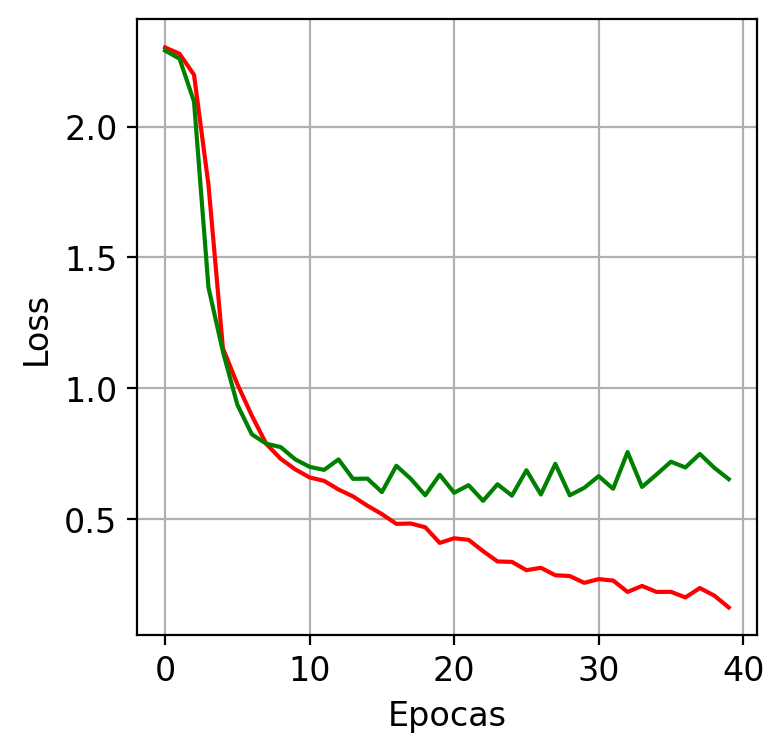

In [ ]:
# plotting training and validation losses
plt.figure(figsize=(4,4))
plt.plot(FMNIST_LeNet5.train_loss_during_training, 'r')
plt.plot(FMNIST_LeNet5.valid_loss_during_training, 'g')
plt.xlabel("Epocas")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [ ]:
# evaluate the model on test dataset
correct = 0
total = 0
for test_data in test_loader:
    total += 1
    inputs, actual_val = test_data
    # perform classification
    predicted_val = FMNIST_LeNet5(torch.autograd.Variable(inputs))
    # convert 'predicted_val' GPU tensor to CPU tensor and extract the column with max_score
    predicted_val = predicted_val.data
    max_score, idx = torch.max(predicted_val, 1)
    # compare it with actual value and estimate accuracy
    correct += (idx == actual_val).sum()

print("Classifier Accuracy: ", (correct/total).item() * 100)

Classifier Accuracy:  79.98999953269958


### Ejercicio de ampliación

Obtenga las predicciones para todo el conjunto de test. Compare con los valores correctos (targets) para los 20 primeros patrones.

In [ ]:
<INSERTAR CÓDIGO AQUÍ>

### Ejercicio de ampliación

Amplíe la clase ``FMNIST_LeNet5`` añadiendo un método ``.predict`` y compruebe que produce los mismos resultados que el código anterior.

In [ ]:
<INSERTAR CÓDIGO AQUÍ>

### Ejercicio de ampliación

Hasta ahora sólo hemos medido el total de errores (Accuracy), sin importar el tipo de equivocación que se produce. Vamos a calcular y representar la **Matriz de confusión** para ver si hay más equivocaciones entre ciertas clases. Puede utilizar la métrica ``confusion_matrix`` de ``sklearn.metrics``. Localice las dos clases que se confunden con mayor frecuencia y represente 5 imágenes de cada una de ellas.

In [ ]:
<INSERTAR CÓDIGO AQUÍ>

### Ejercicio de ampliación

Cuando se entrena esta red con la **totalidad de los datos de entrenamiento Fashion MNIST** **se alcanza fácilmente una accuracy del 90% en el conjuto de test**. Modifique el código para visualizar la **evolución de la accuracy de esta red**, tanto en el conjunto de entrenamiento como en el de validación. Incorpore variantes para mejorar la generalización y por tanto dichas prestaciones.

In [ ]:
<INSERTAR CÓDIGO AQUÍ>